In [ ]:
import marimo as mo

mo.md(
    """
    # Constant Mean Function

    MojoGP currently exposes a learnable **constant** mean in the public
    wrapper API. The mean handles a global vertical offset; the kernel models
    residual variation around that offset.

    This notebook shows two equivalent workflows:

    - omit `init_mean` and let `SingleOutputGP` initialize from `y.mean()`
    - center targets yourself and use `init_mean=0.0`, then add the offset back

    It also shows the main behavior of a constant mean: away from the training
    data, the posterior mean falls back toward the learned baseline rather
    than toward zero. X-dependent mean functions are not currently a public
    MojoGP wrapper feature.
    """
)

# Constant Mean Function

MojoGP currently exposes a learnable **constant** mean in the public
wrapper API. The mean handles a global vertical offset; the kernel models
residual variation around that offset.

This notebook shows two equivalent workflows:

- omit `init_mean` and let `SingleOutputGP` initialize from `y.mean()`
- center targets yourself and use `init_mean=0.0`, then add the offset back

It also shows the main behavior of a constant mean: away from the training
data, the posterior mean falls back toward the learned baseline rather
than toward zero. X-dependent mean functions are not currently a public
MojoGP wrapper feature.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(26)
true_mean = 6.0
X_train = np.linspace(-2.5, 2.5, 70, dtype=np.float32).reshape(-1, 1)
X_test = np.linspace(-7.0, 7.0, 220, dtype=np.float32).reshape(-1, 1)

def residual_signal(X):
    return (0.9 * np.sin(1.6 * X[:, 0]) + 0.25 * np.cos(3.1 * X[:, 0])).astype(
        np.float32
    )

y_latent_train = true_mean + residual_signal(X_train)
y_latent_test = true_mean + residual_signal(X_test)
y_train = (y_latent_train + 0.12 * rng.standard_normal(len(X_train))).astype(
    np.float32
)
auto_init_mean = float(np.mean(y_train))

fig, data_ax = plt.subplots(figsize=(9, 4))
data_ax.scatter(X_train[:, 0], y_train, s=16, alpha=0.55, label="observed train")
data_ax.plot(X_test[:, 0], y_latent_test, "k--", alpha=0.8, label="latent truth")
data_ax.axhline(true_mean, color="tab:green", linestyle=":", label="true offset")
data_ax.axhline(
    auto_init_mean,
    color="tab:purple",
    linestyle="-.",
    label="auto init y.mean()",
)
data_ax.axvspan(-7.0, -2.5, color="0.92", zorder=-1)
data_ax.axvspan(2.5, 7.0, color="0.92", zorder=-1)
data_ax.set_title("A shifted signal with extrapolation regions shaded")
data_ax.legend(fontsize=8)
fig.tight_layout()
mo.mpl.interactive(fig)
interpolation_mask = np.abs(X_test[:, 0]) <= 2.5
far_mask = np.abs(X_test[:, 0]) >= 5.5

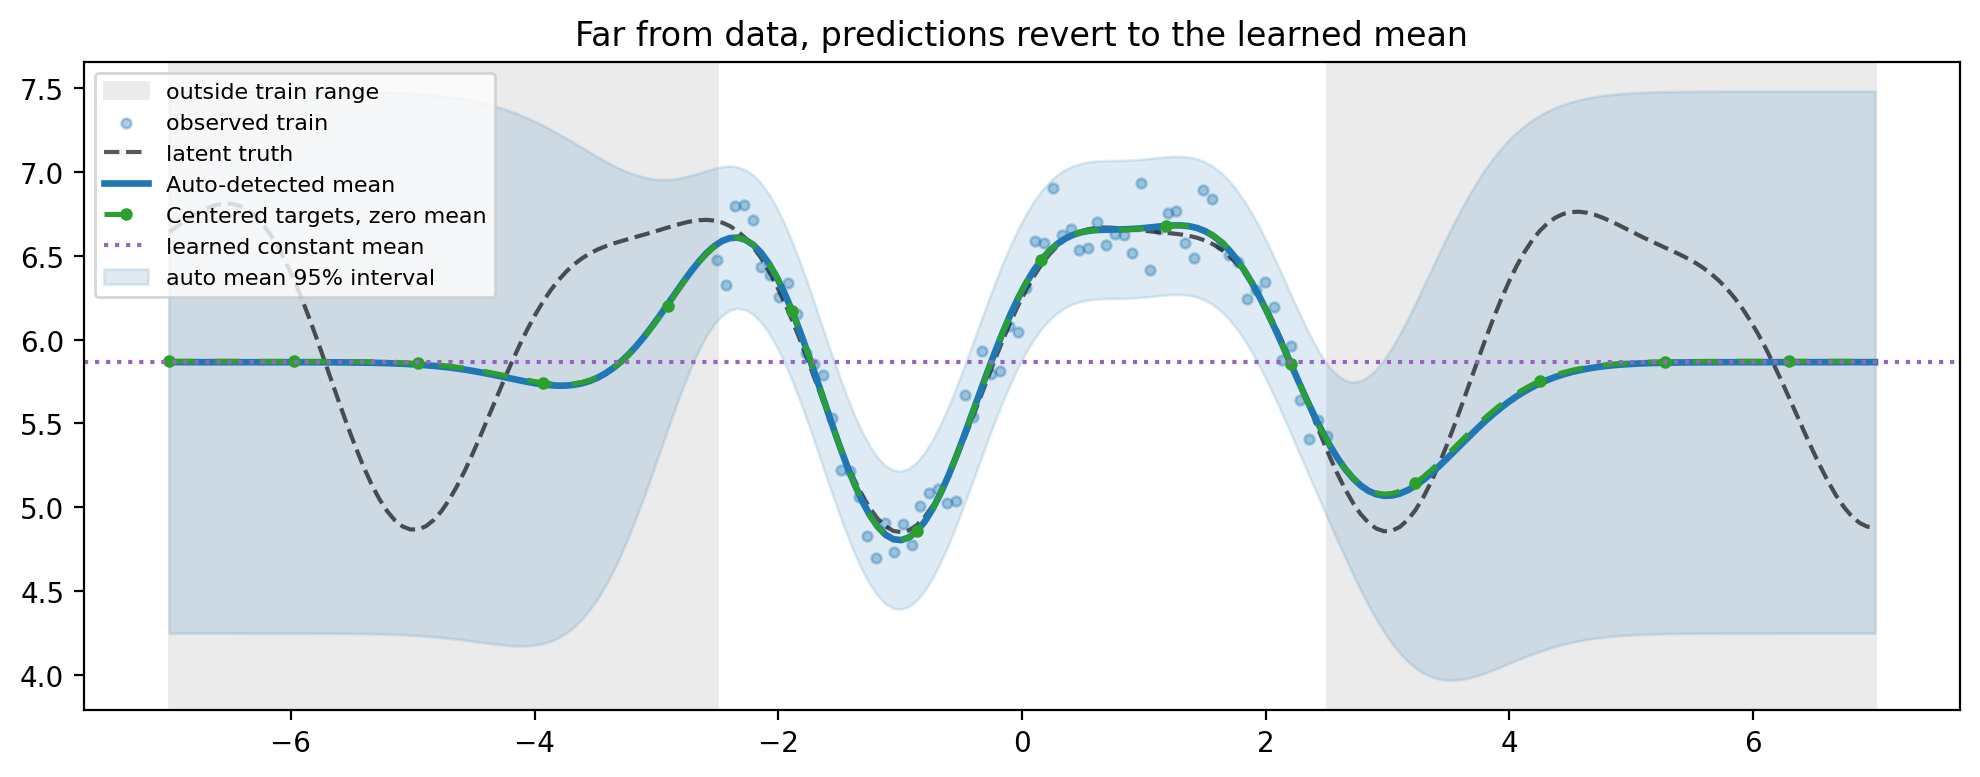

Mean Function Workflows 
 The auto workflow initialized at the observed training mean 6.0399 . The centered-target workflow learns a mean near zero on the centered scale, then adds the training offset back to predictions. Both workflows model the same residual GP around the same display-scale baseline. <marimo-table data-initial-value='[]' data-label='"<span class=\"markdown prose dark:prose-invert contents\"><span class=\"paragraph\">Mean function workflows</span></span>"' data-data='"[{\"Workflow\":\"Auto-detected mean\",\"API pattern\":\"SingleOutputGP(RBF())\",\"Initial mean\":\"6.0399\",\"Learned mean on fit scale\":\"5.8657\",\"Learned mean on display scale\":\"5.8657\",\"Interpolation RMSE\":\"0.0362\",\"Mean predictive std\":\"0.5349\",\"Far-field mean\":\"5.8655\",\"Far-field error vs learned mean\":\"0.0002\",\"Final NLL\":\"-0.1619\"},{\"Workflow\":\"Centered targets, zero mean\",\"API pattern\":\"SingleOutputGP(RBF(), init_mean=0.0)\",\"Initial mean\":\"0.0000\",\"Learned mean on fit scale\":\"-0.1690\",\"Learned mean on display scale\":\"5.8708\",\"Interpolation RMSE\":\"0.0369\",\"Mean predictive std\":\"0.5366\",\"Far-field mean\":\"5.8706\",\"Far-field error vs learned mean\":\"0.0002\",\"Final NLL\":\"-0.1581\"}]"' data-total-rows='2' data-total-columns='10' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-selection='"multi"' data-show-filters='false' data-show-download='false' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'> Prediction Agreement vs Auto Mean 
 These small differences show that auto-detecting the constant mean, and manually centering targets are equivalent ways to handle a global vertical shift for this data. The far-field mean columns show the constant mean's role as the extrapolation baseline. <marimo-table data-initial-value='[]' data-label='"<span class=\"markdown prose dark:prose-invert contents\"><span class=\"paragraph\">Prediction agreement vs auto mean</span></span>"' data-data='"[{\"Workflow\":\"Auto-detected mean\",\"Max mean difference\":\"0.000000\",\"Max std difference\":\"0.000000\"},{\"Workflow\":\"Centered targets, zero mean\",\"Max mean difference\":\"0.021671\",\"Max std difference\":\"0.006104\"}]"' data-total-rows='2' data-total-columns='3' data-max-columns='50' data-banner-text='""' data-pagination='false' data-page-size='10' data-selection='"multi"' data-show-filters='false' data-show-download='false' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'>
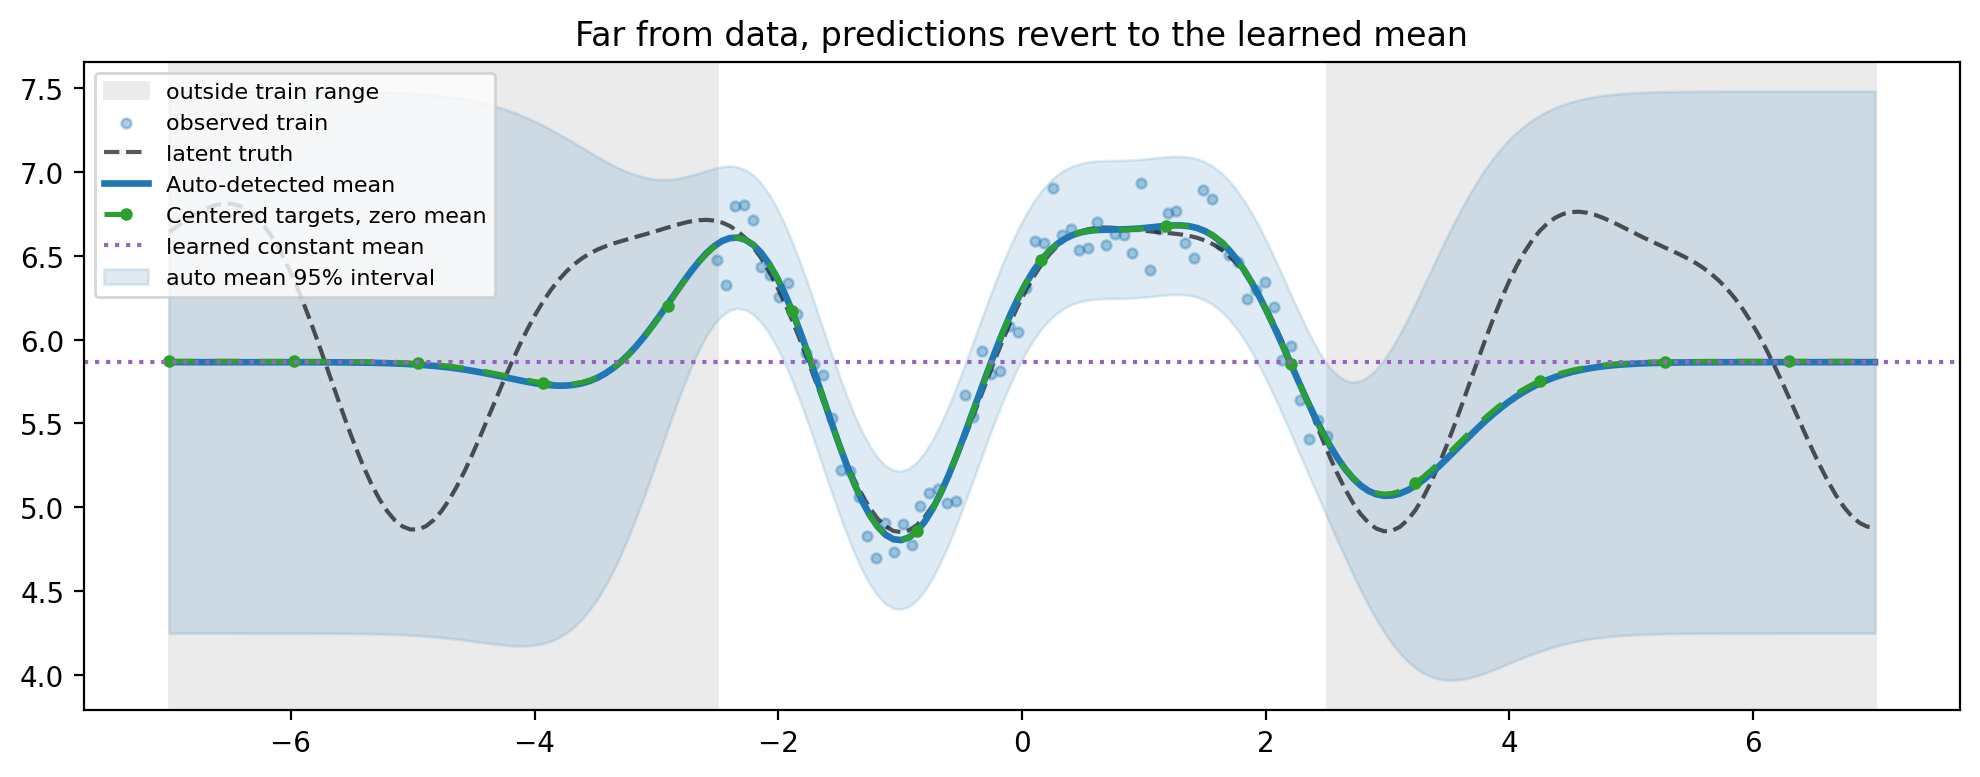

In [ ]:
from mojogp import RBF, SingleOutputGP

def fit_workflow(label, y_fit, init_mean, add_back, api_pattern):
    kwargs = {} if init_mean is None else {"init_mean": float(init_mean)}
    gp = SingleOutputGP(RBF(lengthscale=1.0, outputscale=1.0), **kwargs)
    train_result = gp.fit(
        X_train,
        y_fit,
        max_iterations=30,
        learning_rate=0.035,
        method="materialized",
    )
    prediction = gp.predict(X_test, variance_method="exact")
    display_mean = prediction.mean + add_back
    params = gp.get_learned_params()
    display_learned_mean = float(params["mean"] + add_back)
    far_prediction_mean = float(np.mean(display_mean[far_mask]))
    return {
        "label": label,
        "api_pattern": api_pattern,
        "init_mean": auto_init_mean if init_mean is None else float(init_mean),
        "learned_mean_fit_scale": float(params["mean"]),
        "learned_mean_display_scale": display_learned_mean,
        "rmse": float(
            np.sqrt(
                np.mean(
                    (display_mean[interpolation_mask] - y_latent_test[interpolation_mask])
                    ** 2
                )
            )
        ),
        "mean_std": float(np.mean(prediction.std)),
        "far_prediction_mean": far_prediction_mean,
        "far_mean_error": abs(far_prediction_mean - display_learned_mean),
        "nll": float(train_result.nll),
        "prediction_mean": display_mean,
        "prediction_std": prediction.std,
        "gp": gp,
    }

centered_y_train = (y_train - auto_init_mean).astype(np.float32)
workflows = [
    fit_workflow(
        "Auto-detected mean",
        y_train,
        None,
        0.0,
        "SingleOutputGP(RBF())",
    ),
    fit_workflow(
        "Centered targets, zero mean",
        centered_y_train,
        0.0,
        auto_init_mean,
        "SingleOutputGP(RBF(), init_mean=0.0)",
    ),
]

reference = workflows[0]
for workflow in workflows:
    workflow["max_mean_diff_vs_auto"] = float(
        np.max(np.abs(workflow["prediction_mean"] - reference["prediction_mean"]))
    )
    workflow["max_std_diff_vs_auto"] = float(
        np.max(np.abs(workflow["prediction_std"] - reference["prediction_std"]))
    )

workflow_table = [
    {
        "Workflow": workflow["label"],
        "API pattern": workflow["api_pattern"],
        "Initial mean": f"{workflow['init_mean']:.4f}",
        "Learned mean on fit scale": f"{workflow['learned_mean_fit_scale']:.4f}",
        "Learned mean on display scale": f"{workflow['learned_mean_display_scale']:.4f}",
        "Interpolation RMSE": f"{workflow['rmse']:.4f}",
        "Mean predictive std": f"{workflow['mean_std']:.4f}",
        "Far-field mean": f"{workflow['far_prediction_mean']:.4f}",
        "Far-field error vs learned mean": f"{workflow['far_mean_error']:.4f}",
        "Final NLL": f"{workflow['nll']:.4f}",
    }
    for workflow in workflows
]
agreement_table = [
    {
        "Workflow": workflow["label"],
        "Max mean difference": f"{workflow['max_mean_diff_vs_auto']:.6f}",
        "Max std difference": f"{workflow['max_std_diff_vs_auto']:.6f}",
    }
    for workflow in workflows
]

fig_pred, pred_ax = plt.subplots(figsize=(10, 4))
pred_ax.axvspan(-7.0, -2.5, color="0.92", zorder=-1, label="outside train range")
pred_ax.axvspan(2.5, 7.0, color="0.92", zorder=-1)
pred_ax.scatter(X_train[:, 0], y_train, s=12, alpha=0.35, label="observed train")
pred_ax.plot(X_test[:, 0], y_latent_test, "k--", alpha=0.65, label="latent truth")
line_styles = [
    {
        "color": "tab:blue",
        "linestyle": "-",
        "linewidth": 2.4,
        "marker": None,
        "markevery": None,
    },
    {
        "color": "tab:green",
        "linestyle": (0, (5, 4)),
        "linewidth": 1.8,
        "marker": "o",
        "markevery": 16,
    },
]
for workflow, style in zip(workflows, line_styles):
    pred_ax.plot(
        X_test[:, 0],
        workflow["prediction_mean"],
        color=style["color"],
        linestyle=style["linestyle"],
        label=workflow["label"],
        linewidth=style["linewidth"],
        marker=style["marker"],
        markevery=style["markevery"],
        markersize=3.5,
    )
auto_std = reference["prediction_std"]
pred_ax.axhline(
    reference["learned_mean_display_scale"],
    color="tab:purple",
    linestyle=":",
    label="learned constant mean",
)
pred_ax.fill_between(
    X_test[:, 0],
    reference["prediction_mean"] - 2 * auto_std,
    reference["prediction_mean"] + 2 * auto_std,
    color="tab:blue",
    alpha=0.14,
    label="auto mean 95% interval",
)
pred_ax.set_title("Far from data, predictions revert to the learned mean")
pred_ax.legend(fontsize=8, loc="upper left")
fig_pred.tight_layout()

mo.vstack(
    [
        mo.mpl.interactive(fig_pred),
        mo.md(
            "## Mean Function Workflows\n\n"
            f"The auto workflow initialized at the observed training mean `{auto_init_mean:.4f}`. "
            "The centered-target workflow learns a mean near zero on the centered scale, "
            "then adds the training offset back to predictions. Both workflows model the "
            "same residual GP around the same display-scale baseline."
        ),
        mo.ui.table(workflow_table, label="Mean function workflows"),
        mo.md(
            "## Prediction Agreement vs Auto Mean\n\n"
            "These small differences show that auto-detecting the constant mean, "
            "and manually centering targets are equivalent ways to handle a global "
            "vertical shift for this data. The far-field mean columns show the constant "
            "mean's role as the extrapolation baseline."
        ),
        mo.ui.table(agreement_table, label="Prediction agreement vs auto mean"),
    ]
)